# SUP ML 1 - PREPROCESSING

# Librerias

In [ ]:
# gestión de datos
import numpy as np
import pandas as pd
import pickle

# gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# quitar alertas
import warnings
warnings.filterwarnings("ignore")

# para visualizar mas columnas en un df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.random.seed(42)

# Importar train data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Master_Data_Science/Aprendizaje supervisado/DSC-0924-Entregable 2-Buixeda_Urbina_Longobardi_Farres/telecom_churn_TRAINTEST (1).csv')

In [ ]:
df_predict = pd.read_csv('/content/drive/MyDrive/Master_Data_Science/Aprendizaje supervisado/DSC-0924-Entregable 2-Buixeda_Urbina_Longobardi_Farres/telecom_churn_PREDICT (1).csv')

# EDA: Analisis Exploratorio

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 100 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rev               89866 non-null  float64
 1   mou               89866 non-null  float64
 2   totmrc            89866 non-null  float64
 3   da                89866 non-null  float64
 4   ovrmou            89866 non-null  float64
 5   ovrrev            89866 non-null  float64
 6   vceovr            89866 non-null  float64
 7   datovr            89866 non-null  float64
 8   roam              89866 non-null  float64
 9   change_mou        89405 non-null  float64
 10  change_rev        89405 non-null  float64
 11  drop_vce          90000 non-null  float64
 12  drop_dat          90000 non-null  float64
 13  blck_vce          90000 non-null  float64
 14  blck_dat          90000 non-null  float64
 15  unan_vce          90000 non-null  float64
 16  unan_dat          90000 non-null  float

In [ ]:
df.head()

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,change_rev,drop_vce,drop_dat,blck_vce,blck_dat,unan_vce,unan_dat,plcd_vce,plcd_dat,recv_vce,recv_sms,comp_vce,comp_dat,custcare,ccrndmou,cc_mou,inonemin,threeway,mou_cvce,mou_cdat,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,mou_pead,opk_vce,opk_dat,mou_opkv,mou_opkd,drop_blk,attempt,complete,callfwdv,callwait,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [ ]:
df.shape

(90000, 100)

Estamos trabajando con un dataset de 100 columnas en el dataframe de entrenamiento y 99 en el dataset de predicción. La diferencia es la columna target "churn". "Churn" indica si el cliente abandona dentro del intervalo de 31 y 60 días.

## Distribución del target

In [ ]:
target = 'churn'

churn
1    45800
0    44200
Name: count, dtype: int64


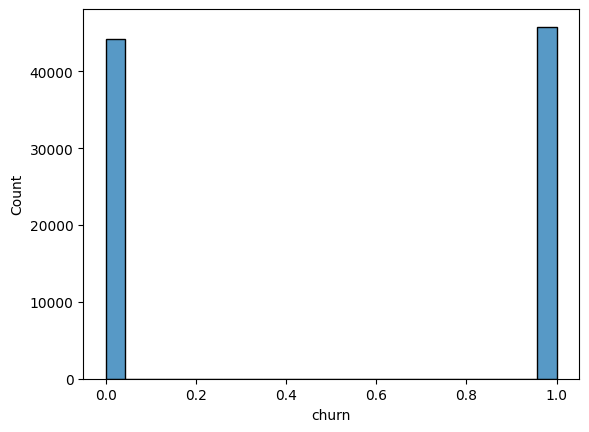

In [ ]:
print(df[target].value_counts())
sns.histplot(data = df, x = target)
plt.show()

## Analisis Univariable

* Distribucion de cada variable

In [ ]:
# separamos variables categoricas, numericas y boolean
def obtener_lista_variables(dataset):
    lista_numericas = []
    lista_boolean = []
    lista_categoricas = []
    for i in dataset:
        if    (dataset[i].dtype.kind == "f" or dataset[i].dtype.kind == "i") and len(dataset[i].dropna().unique()) != 2  and i not in target:
              lista_numericas.append(i)
        elif  (dataset[i].dtype.kind == "f" or dataset[i].dtype.kind == "i")  and len(dataset[i].dropna().unique()) == 2  and i not in target:
              lista_boolean.append(i)
        elif  (dataset[i].dtype.kind == "O")  and i not in target:
              lista_categoricas.append(i)

    return lista_numericas, lista_boolean, lista_categoricas

In [ ]:
lista_numericas, lista_boolean, lista_categoricas = obtener_lista_variables(df)

In [ ]:
print(f"Total de variables en el dataset: {len(df.columns)}")
print(f"Variables categoricas: {len(lista_categoricas)}")
print(f"Variables booleanas: {len(lista_boolean)}")
print(f"Variables Numericas: {len(lista_numericas)}")

Total de variables en el dataset: 100
Variables categoricas: 21
Variables booleanas: 3
Variables Numericas: 75


Para el análisis de las variables numericas, primero visualizamos los datos estadísticos de las variables y a continuación visualizamos la distribución gráficamente.

In [ ]:
df[lista_numericas].describe()

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,change_rev,drop_vce,drop_dat,blck_vce,blck_dat,unan_vce,unan_dat,plcd_vce,plcd_dat,recv_vce,recv_sms,comp_vce,comp_dat,custcare,ccrndmou,cc_mou,inonemin,threeway,mou_cvce,mou_cdat,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,mou_pead,opk_vce,opk_dat,mou_opkv,mou_opkd,drop_blk,attempt,complete,callfwdv,callwait,months,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,hnd_price,phones,models,lor,adults,income,numbcars,eqpdays,Customer_ID
count,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89405.000000,89405.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,88593.000000,88593.000000,88593.000000,89296.000000,89999.000000,89999.000000,63498.000000,69967.000000,67804.000000,46432.000000,89999.000000,9.000000e+04
mean,58.312895,504.277946,45.880669,0.877813,40.798976,13.289932,13.046046,0.240786,1.308197,-13.786987,-1.074666,5.769639,0.037837,3.999448,0.019737,26.843561,0.027811,141.375341,0.805435,53.713298,0.047781,106.483091,0.720050,1.648754,4.344852,3.444618,28.909037,0.269522,221.363949,1.689888,109.071366,24.268663,27.785579,7.712004,17.676245,86.999369,0.334957,171.309285,0.654335,64.103954,0.385096,159.080481,1.035109,9.826661,142.180776,107.203141,0.010415,1.732817,19.263856,1.555067,1.366522,2970.669433,7874.976570,1065.717715,994.546384,7776.807032,2931.320344,57.288343,472.052308,170.568866,510.539844,178.227000,58.802889,501.598490,176.320082,58.266691,99.709575,1.802987,1.556184,6.180856,2.538197,5.809274,1.568896,402.419438,1.045000e+06
std,46.084103,516.170057,23.370435,2.173665,96.970619,30.123282,29.719581,3.012631,15.374215,271.624916,50.565668,8.673272,0.885448,10.603489,0.699317,37.315217,0.501246,155.486573,8.455179,85.537833,2.176283,116.845898,7.679230,5.148484,12.141729,10.049161,54.960177,1.003104,257.220079,21.905864,160.081469,33.913196,47.948938,15.908932,40.382222,102.308064,3.890521,205.794020,7.335297,89.736523,4.393926,228.966797,16.988064,15.081650,156.468555,117.776670,0.465963,5.260407,9.149764,1.095305,0.661085,3887.921200,8869.646079,865.305299,851.715318,8802.189472,3855.692056,35.430616,425.257319,165.134394,524.737209,191.398108,46.476204,489.911616,181.593174,40.483529,60.788920,1.319121,0.900798,4.741242,1.452650,2.176928,0.628308,252.821660,2.598091e+04
min,-5.862500,0.000000,-26.915000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.740000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,0.000000,0.000000,23.750000,9.320000,0.000000,0.000000,2.910000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-2.000000,9.989998,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,-5.000000,1.000001e+06
25%,33.027500,148.500000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-85.750000,-7.212500,0.666667,0.000000,0.000000,0.000000,4.666667,0.000000,36.666667,0.000000,5.0000

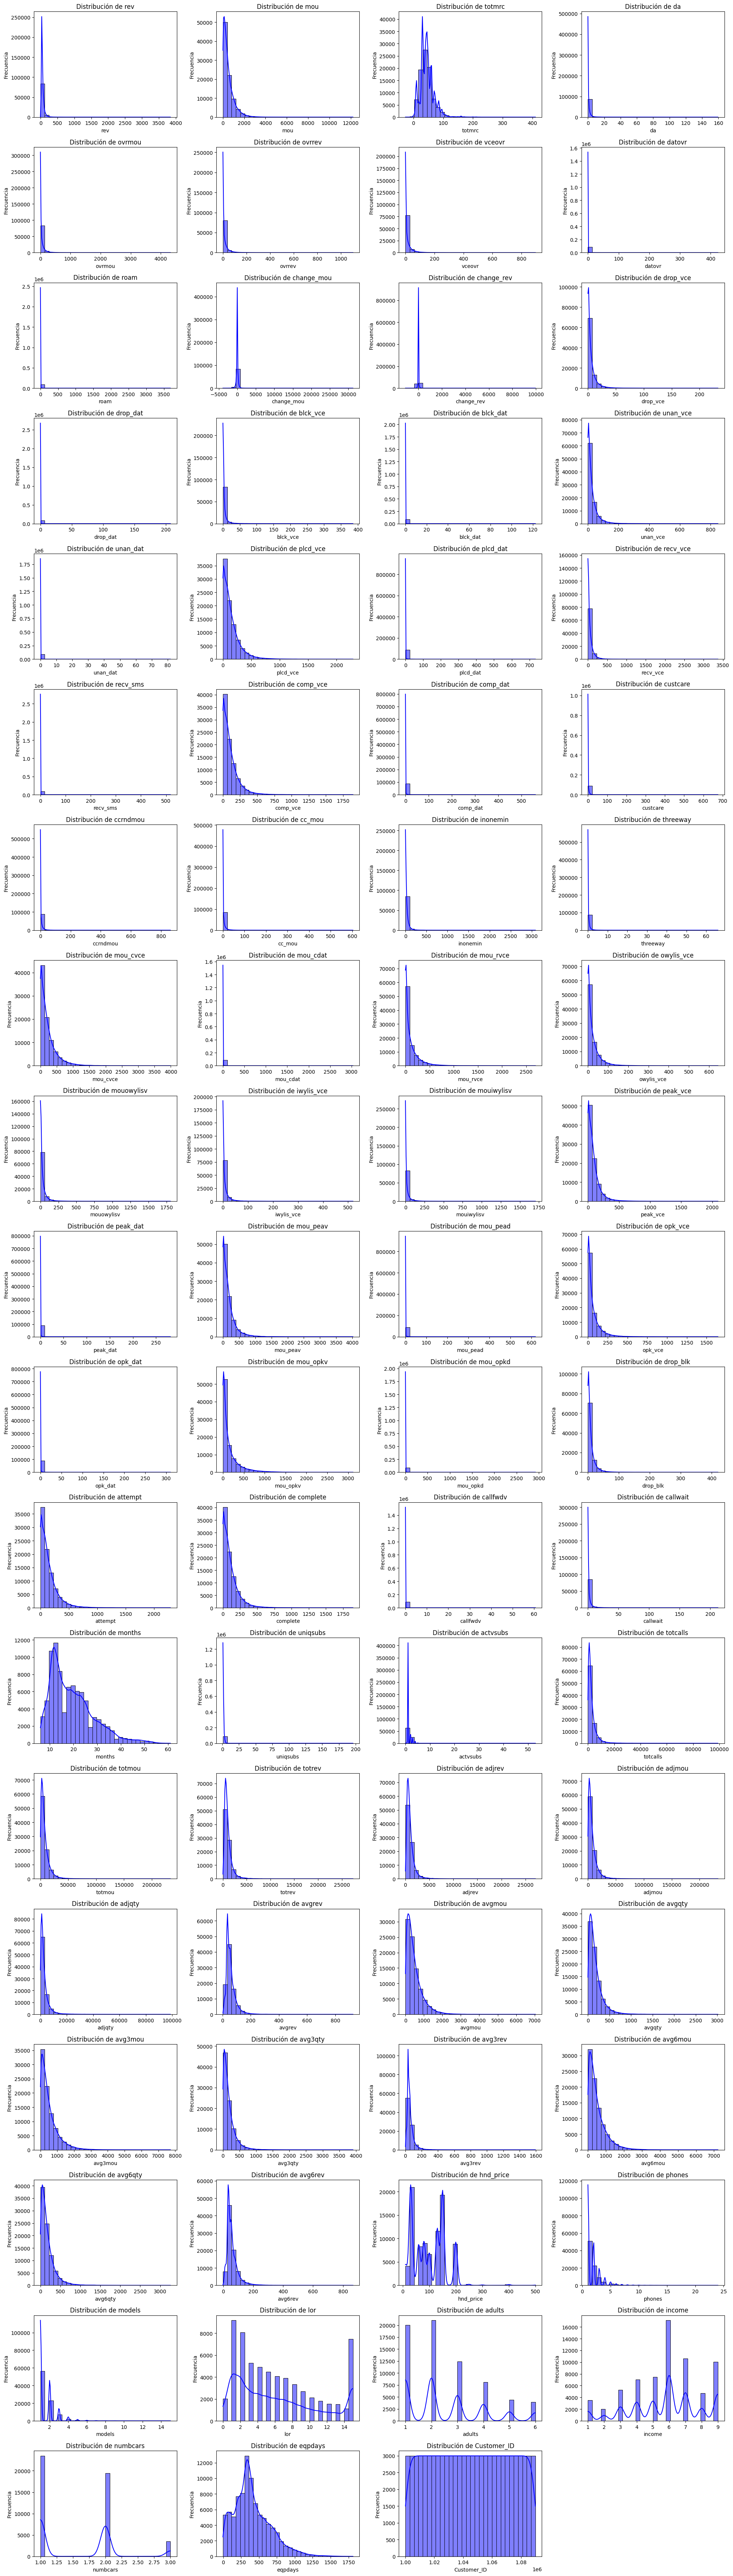

In [ ]:
# variables para hacer 4 scatterplot por línea
graficos_por_fila = 4
variables = list(lista_numericas)
num_variables = len(variables)

# Configura la cuadrícula de gráficos
fig, axes = plt.subplots(nrows = (num_variables + graficos_por_fila - 1) // graficos_por_fila, ncols = graficos_por_fila, figsize = (20, 70))
axes = axes.flatten()

# Aplanar la matriz de ejes para iterar fácilmente
axes = axes.flatten()

# Iterar sobre las columnas y graficar
for i, var in enumerate(variables):
    ax = axes[i]
    sns.histplot(df[var], kde = True, bins = 30, color = 'blue', ax = ax)
    ax.set_title(f"Distribución de {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Frecuencia")

# Ocultar ejes sobrantes si hay menos gráficos que subplots
for ax in axes[len(variables):]:
    ax.axis('off')

# Ajustar el espacio entre subplots
plt.tight_layout()
plt.show()

Con esta primera exploración de las variables numericas, nos damos cuenta de:

1. Existen valores outliers en la mayoria de ellas
2. La variable customer ID nos sirve como identificador unico para cada cliente

Ahora vamos a explorar las variables categoricas. En este caso, deberemos convertirlas a numericas. Analizaremos la distribución de las frecuencias de las categorías usando una tabla para identificar categorías poco frecuentes que podrían ser agrupadas.

Si hay muchas categorías con baja frecuencia, las agruparemos en una nueva categoría.

Si el número de categorías es elevado (>15-20), consideraremos reducirlas mediante agrupación, codificación oridinal, si hay algun orden lógico, o target encoding.

In [ ]:
for i in lista_boolean:
  print(f'\nVariable: {i}\n')
  freq = df[i].value_counts()
  percent = (freq / len(df))*100
  result = pd.DataFrame({'Frecuencia': freq, '% sobre el total': percent})
  print(result)


Variable: truck

       Frecuencia  % sobre el total
truck                              
0.0         71088         78.986667
1.0         17461         19.401111

Variable: rv

     Frecuencia  % sobre el total
rv                               
0.0       80857         89.841111
1.0        7692          8.546667

Variable: forgntvl

          Frecuencia  % sobre el total
forgntvl                              
0.0            83302         92.557778
1.0             5247          5.830000


In [ ]:
for i in lista_categoricas:
  print(f'\nVariable: {i}\n')
  freq = df[i].value_counts()
  percent = (freq / len(df))*100
  result = pd.DataFrame({'Frecuencia': freq, '% sobre el total': percent})
  print(result)


Variable: new_cell

          Frecuencia  % sobre el total
new_cell                              
U              58812         65.346667
Y              18114         20.126667
N              13074         14.526667

Variable: crclscod

          Frecuencia  % sobre el total
crclscod                              
AA             34152         37.946667
A              15602         17.335556
BA             11270         12.522222
CA              7389          8.210000
EA              5521          6.134444
B               3743          4.158889
DA              3201          3.556667
ZA              3177          3.530000
C               1418          1.575556
A2               771          0.856667
U                429          0.476667
E                330          0.366667
E4               305          0.338889
GA               265          0.294444
D                244          0.271111
G                236          0.262222
I                231          0.256667
JF               192  

## Analisis Variable-Target

* Relacion target-variable

In [ ]:
print(f"Calculamos la media de las variables numericas agrupando por 'churn', y la diferenica.")

stats = df.groupby('churn')[lista_numericas].mean().T
stats['diff'] = stats[1] - stats[0]
stats.columns = ['Mean_Churn_0', 'Mean_Churn_1', 'Mean_Difference']
pd.DataFrame(stats)

Calculamos la media de las variables numericas agrupando por 'churn', y la diferenica.


,Mean_Churn_0,Mean_Churn_1,Mean_Difference
rev,5.898814e+01,5.765953e+01,-1.328612
mou,5.346992e+02,4.748424e+02,-59.856799
totmrc,4.748175e+01,4.433147e+01,-3.150277
da,9.155460e-01,8.413020e-01,-0.074244
ovrmou,3.918931e+01,4.235649e+01,3.167182
ovrrev,1.263506e+01,1.392359e+01,1.288529
vceovr,1.239381e+01,1.367715e+01,1.283345
datovr,2.374242e-01,2.440386e-01,0.006614
roam,1.171273e+00,1.440684e+00,0.269411
change_mou,-4.884399e+00,-2.246132e+01,-17.576924


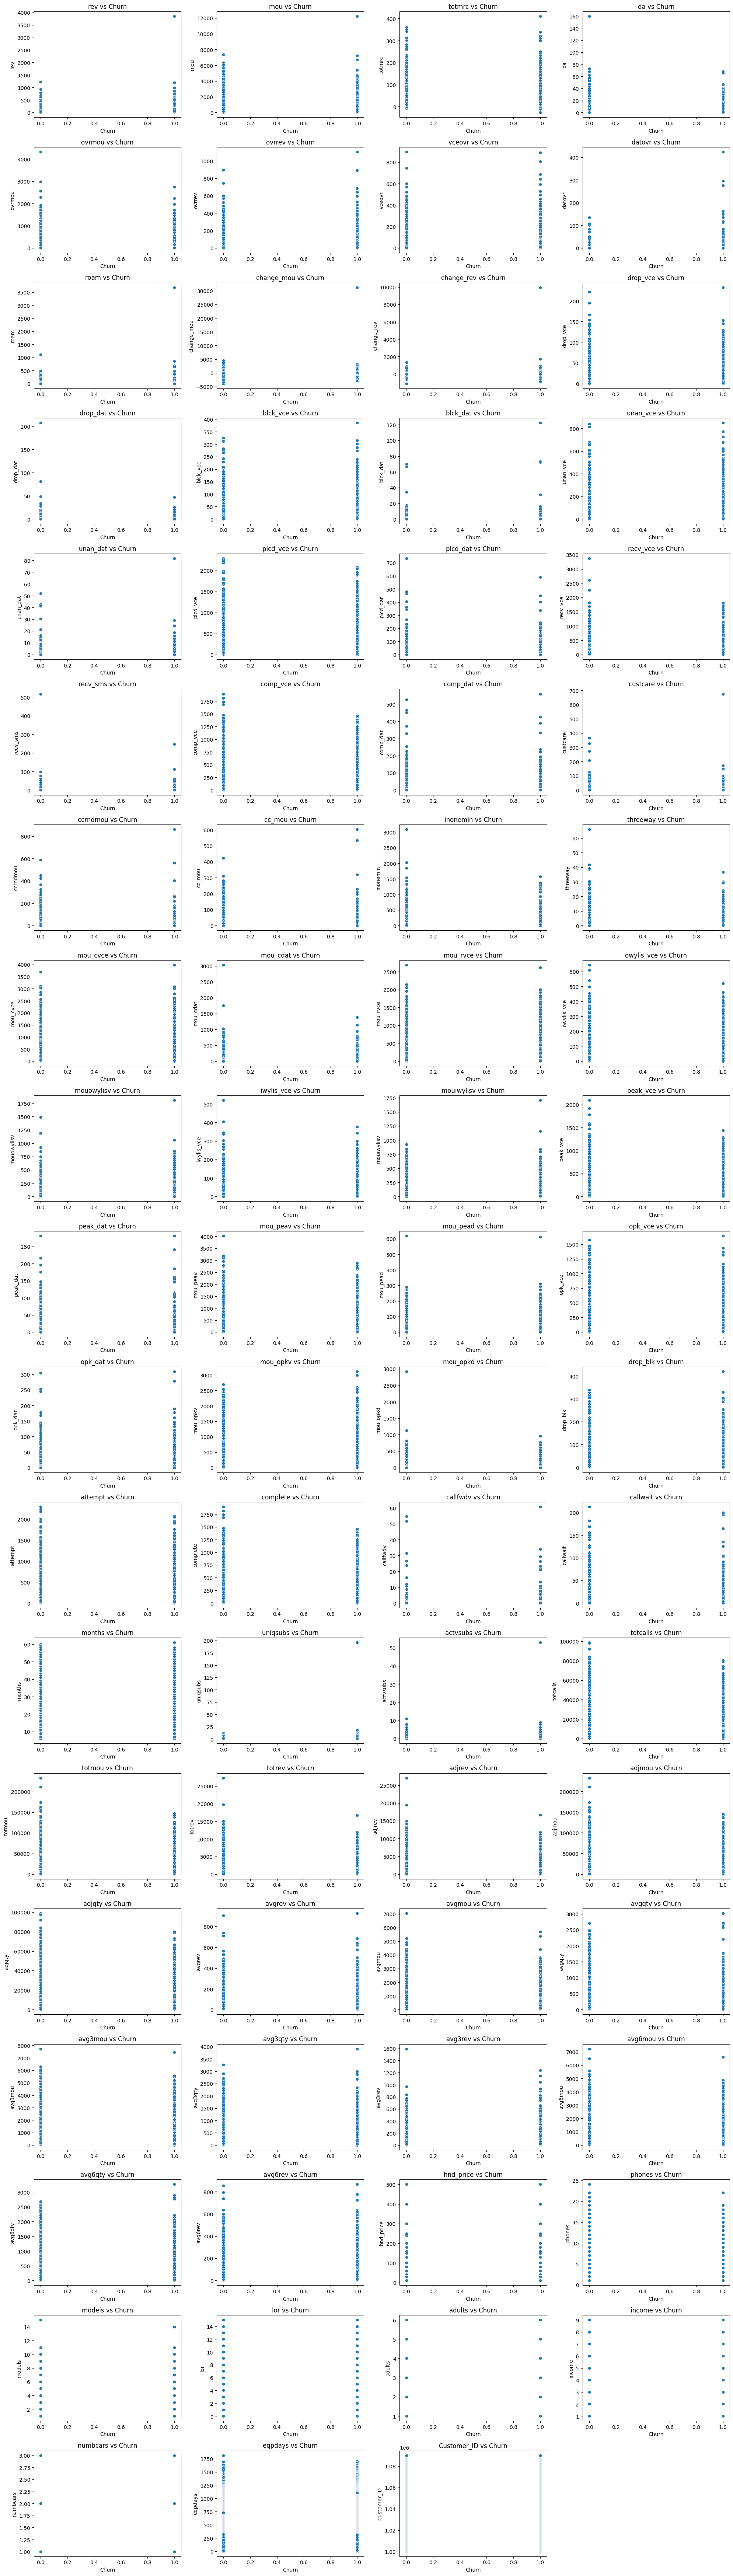

In [ ]:
# variables para hacer 4 scatterplot por línea
graficos_por_fila = 4
variables = list(lista_numericas)
num_variables = len(variables)

# Configura la cuadrícula de gráficos
fig, axes = plt.subplots(nrows = (num_variables + graficos_por_fila - 1) // graficos_por_fila, ncols = graficos_por_fila, figsize = (20, 70))
axes = axes.flatten()

# Aplanar la matriz de ejes para iterar fácilmente
axes = axes.flatten()

# Iterar sobre las columnas y graficar
for i, var in enumerate(variables):
    ax = axes[i]
    sns.scatterplot(x = 'churn', y = var, data = df, ax = ax)
    ax.set_title(f'{var} vs Churn')
    ax.set_xlabel('Churn')
    ax.set_ylabel(var)


# Ocultar ejes sobrantes si hay menos gráficos que subplots
for ax in axes[len(variables):]:
    ax.axis('off')

# Ajustar el espacio entre subplots
plt.tight_layout()
plt.show()


Observamos un valor outlier que destaca en casi todos los graficos. Vamos a visualizar este registro espeífico y a eliminarlo en caso de que sea necesario.

In [ ]:
df[df['rev'] > 2000]

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,change_rev,drop_vce,drop_dat,blck_vce,blck_dat,unan_vce,unan_dat,plcd_vce,plcd_dat,recv_vce,recv_sms,comp_vce,comp_dat,custcare,ccrndmou,cc_mou,inonemin,threeway,mou_cvce,mou_cdat,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,mou_pead,opk_vce,opk_dat,mou_opkv,mou_opkd,drop_blk,attempt,complete,callfwdv,callwait,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
39170,3843.2625,12206.75,30.0,0.0,82.25,28.8075,28.6125,0.195,3685.2,31219.25,9963.6575,25.0,0.0,0.333333,0.0,3.0,0.0,331.0,0.333333,52.0,0.0,304.666667,0.333333,3.0,3.666667,1.31,36.333333,0.0,270.003333,0.04,45.28,36.0,21.796667,3.333333,3.14,205.333333,0.333333,176.513333,0.04,149.333333,0.0,138.77,0.0,25.333333,331.333333,305.0,0.0,0.0,1,16,1,1,Y,EA,N,3359,10243.0,2609.18,2549.68,10216.0,3342,169.98,681.07,222.8,1800,367,522,1098.0,260.0,318.0,U,NEW YORK CITY AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,R,1.0,M,S,3.0,M,1.0,NaN,C,J,0.0,H,U,U,Y,Y,Y,Y,54.0,1039171


In [ ]:
df = df[df['rev'] <= 2000]

# Restablecemos el indice
df = df.reset_index(drop = True)

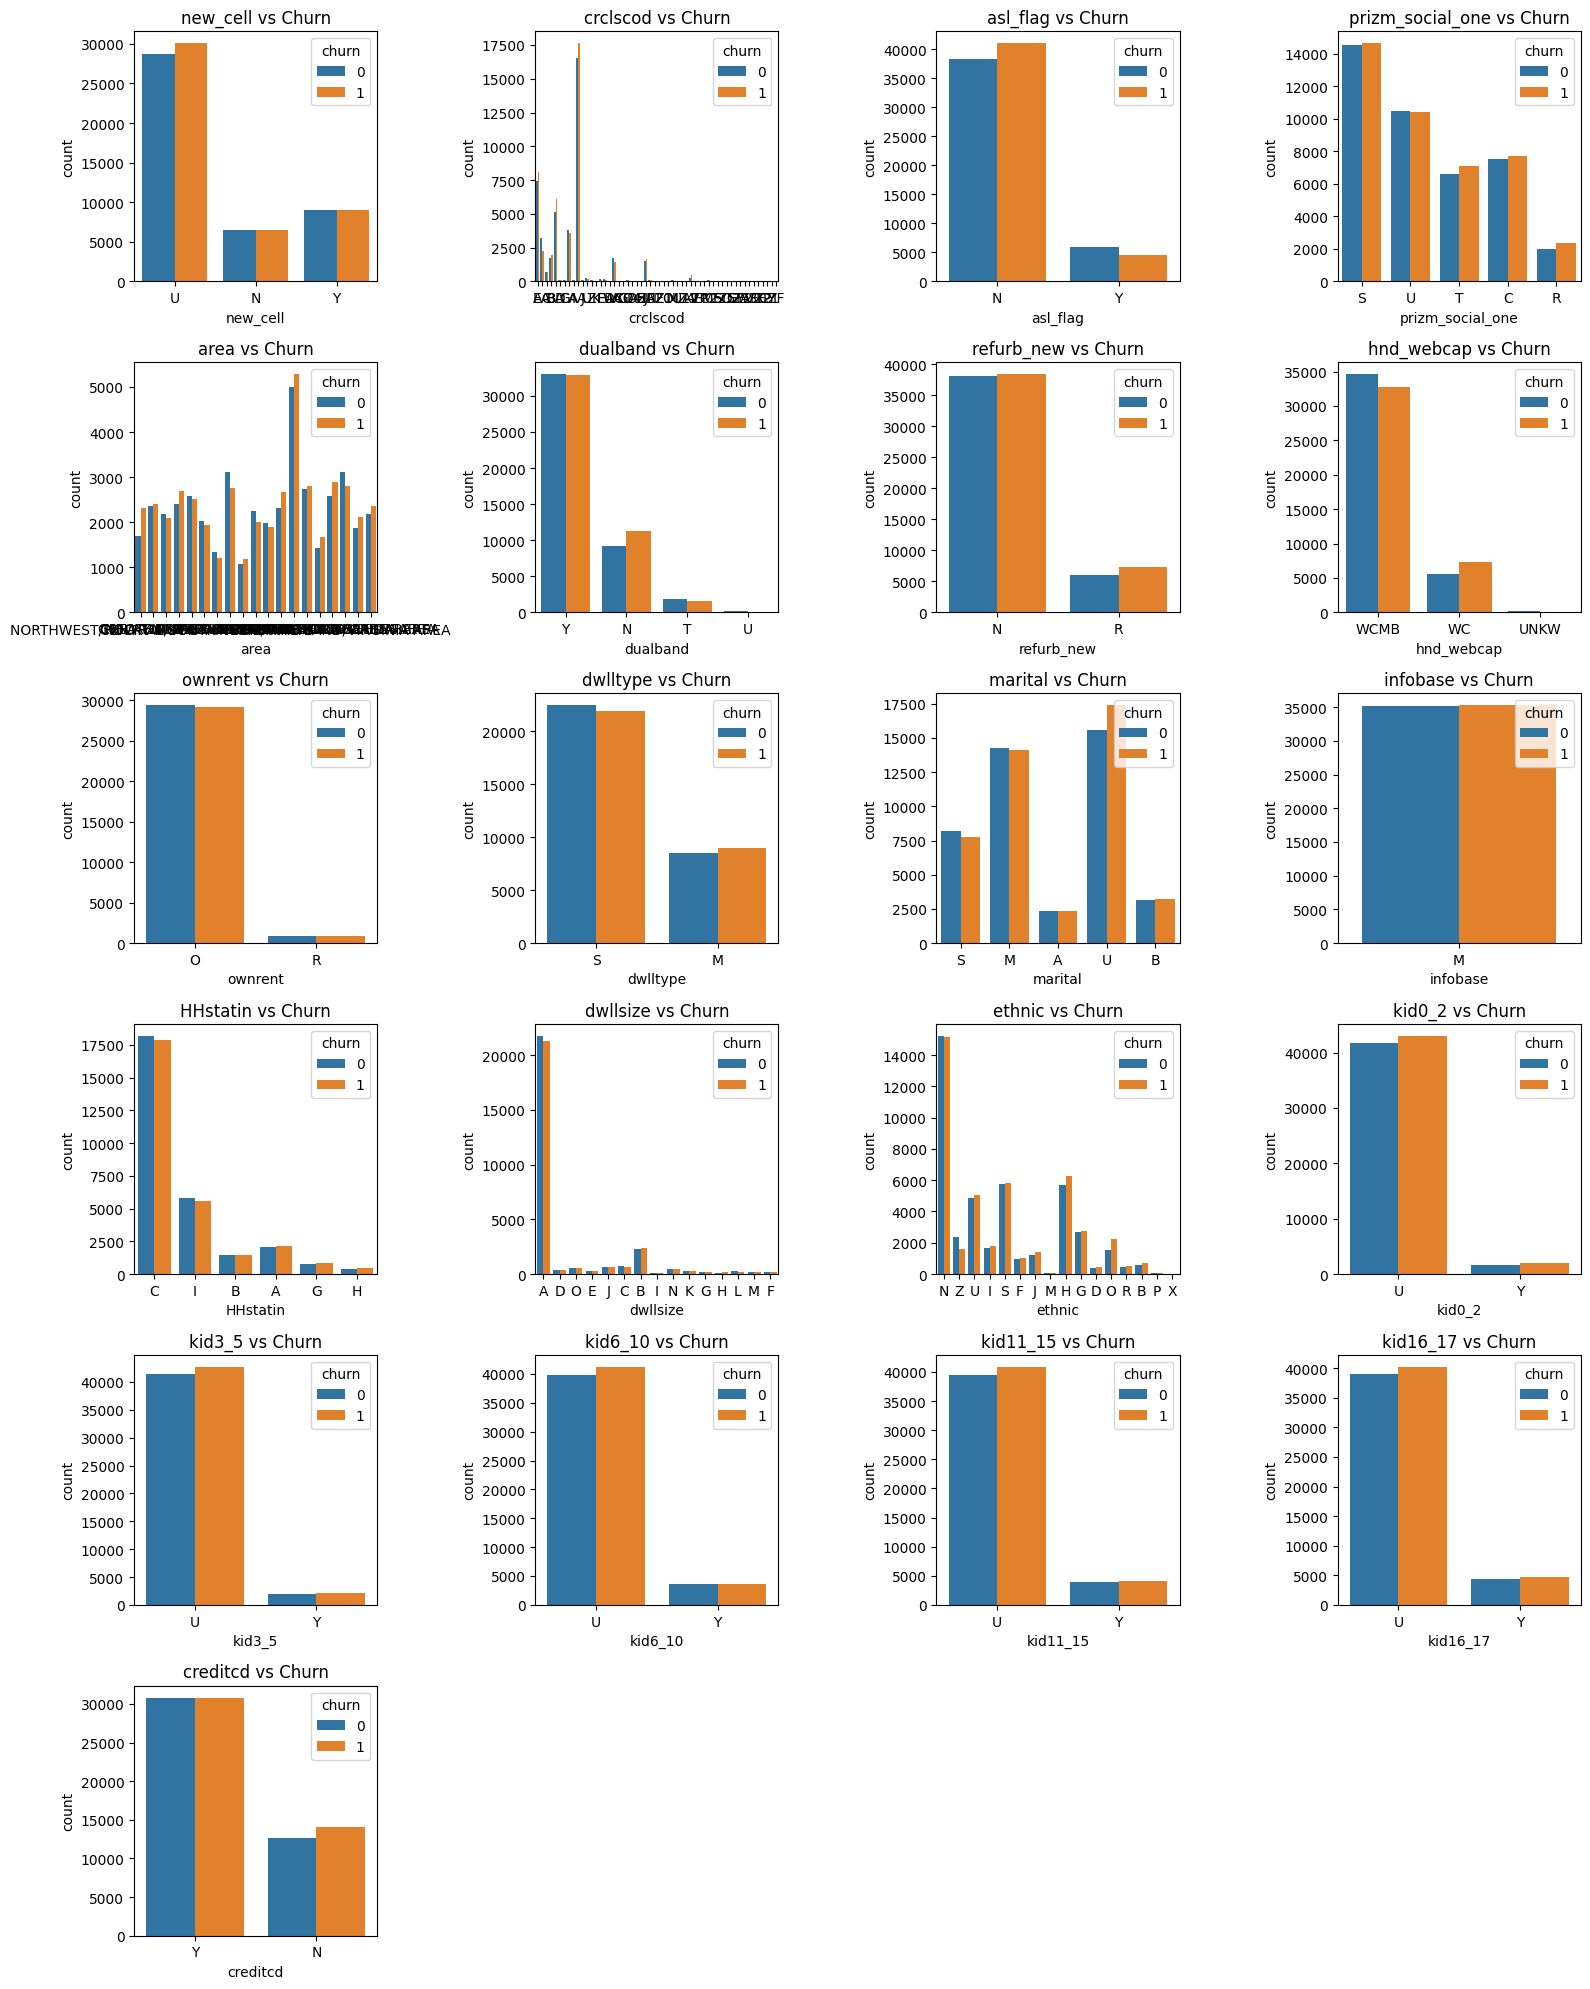

In [ ]:
# variables para hacer 4 scatterplot por línea
graficos_por_fila = 4
variables = list(lista_categoricas)
num_variables = len(variables)

# Configura la cuadrícula de gráficos
fig, axes = plt.subplots(nrows = (num_variables + graficos_por_fila - 1) // graficos_por_fila, ncols = graficos_por_fila, figsize = (16, 20))
axes = axes.flatten()

# Aplanar la matriz de ejes para iterar fácilmente
axes = axes.flatten()

# Iterar sobre las columnas y graficar
for i, var in enumerate(variables):
    ax = axes[i]
    sns.countplot(x = var, hue = 'churn', data = df, ax = ax)
    ax.set_title(f'{var} vs Churn')
    #ax.set_xlabel(var)
    #ax.set_ylabel("Frecuencia")

# Ocultar ejes sobrantes si hay menos gráficos que subplots
for ax in axes[len(variables):]:
    ax.axis('off')

# Ajustar el espacio entre subplots
plt.tight_layout()
plt.show()

# Data Cleaning

* Eliminar filas sin target informado.
* Eliminar filas duplicadas (si tenemos ID, solo puede haber 1 registro por ID)
* Eliminar filas/columnas vacías y columnas irrelevantes
* Corregir data types incorrectos
* Categoricos: Corregir literales incorrectos (acentos, erratas, etc)
* Fechas y textos: convertir a variables numericas (hour, day, month, year...) o categoricas (weekday_name...)

In [ ]:
sin_target = df[target].isna().sum()

print(f"Tenemos {sin_target} filas sin target informado.")

Tenemos 0 filas sin target informado.


In [ ]:
dup = df.duplicated().sum()
cus_dup = df['Customer_ID'].duplicated().sum()

print(f"En el dataset tenemos {dup} filas dulicadas.")
print(f"Hay {cus_dup} Customer_ID duplicados en el dataset.")

En el dataset tenemos 0 filas dulicadas.
Hay 0 Customer_ID duplicados en el dataset.


In [ ]:
print(f"Tabla con el numero de nulos y el porcentaje de nulos de cada variable")
miss = df.isnull().sum().sort_values(ascending = False).head(42)
miss_per = (miss / len(df))*100

# Tabla de nulos
pd.DataFrame({'No. missing values': miss, '% of missing data': miss_per.values})

Tabla con el numero de nulos y el porcentaje de nulos de cada variable


,No. missing values,% of missing data
numbcars,43484,48.388138
dwllsize,33700,37.500695
HHstatin,32956,36.672787
ownrent,29423,32.741334
dwlltype,27917,31.065487
lor,26445,29.427475
income,22140,24.636955
adults,19981,22.234463
infobase,19352,21.534524
hnd_webcap,9487,10.556947


Consideramos como variables irrelevantes estas con un mayor porcentaje de valores nulos. Consideramos eliminar aquellas columnas con más del 30% de valores nulos, como ``numbcars``, ``dwllsize``, ``HHstatin``, ``ownrent``, ``dwlltype``, y ``lor``. Si estas columnas no tienen una correlación fuerte con el objetivo (abandono del cliente, `churn`), su presencia podría reducir la precisión del modelo debido al ruido.

In [ ]:
# eliminamos las columnas con altos valores nulos
df.drop(columns = ['numbcars', 'dwllsize', 'HHstatin', 'ownrent', 'dwlltype', 'lor'], inplace = True, axis = 1)
df_predict.drop(columns = ['numbcars', 'dwllsize', 'HHstatin', 'ownrent', 'dwlltype', 'lor'], inplace = True, axis = 1)
print('ELIMINAMOS LAS VARIABLES: NUMBCARS, DWLLSIZE, HHSTATIN, OWNRENT, DWLLTYPE, LOR DEL DATASET.')

ELIMINAMOS LAS VARIABLES: NUMBCARS, DWLLSIZE, HHSTATIN, OWNRENT, DWLLTYPE, LOR DEL DATASET.


In [ ]:
# actualizamos las listas
lista_numericas, lista_boolean, lista_categoricas = obtener_lista_variables(df)

**CATEGÓRICAS**

In [ ]:
# analizo las que tienen menos de 5 valores distintos que son las que quizás pueda transformar en Booleanas
for variable in lista_categoricas:
        if len(df[variable].unique()) < 5:
            print(f'{variable}:\n{df[variable].unique()}')

new_cell:
['U' 'N' 'Y']
asl_flag:
['N' 'Y']
refurb_new:
['N' 'R' nan]
hnd_webcap:
['WCMB' 'WC' nan 'UNKW']
infobase:
['M' nan]
kid0_2:
['U' 'Y' nan]
kid3_5:
['U' 'Y' nan]
kid6_10:
['U' 'Y' nan]
kid11_15:
['U' 'Y' nan]
kid16_17:
['U' 'Y' nan]
creditcd:
['Y' 'N' nan]


'Kid': cada una de las variables por separado tiene muy poco peso, pues la mayoria de observaicones estan en el U o nan. Lo que haremos será crear una nueva variable general que indicará si tiene kids o no.

In [ ]:
# Crear una nueva columna que sea True si alguna de las variables tiene al menos un 'Y'
df['has_kid'] = df[['kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17']].apply(lambda row: 'Y' in row.values, axis = 1)
df_predict['has_kid'] = df_predict[['kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17']].apply(lambda row: 'Y' in row.values, axis = 1)
print(f"CREAMOS UNA NUEVA VARIABLE QUE ES TRUE SI ALGUNA DE LAS VARIABLES KID TIENE AL MENOS UNA Y. ")

CREAMOS UNA NUEVA VARIABLE QUE ES TRUE SI ALGUNA DE LAS VARIABLES KID TIENE AL MENOS UNA Y. 


In [ ]:
print(f"COMPROBAMOS QUE LOS NULOS HAN SIDO TRATADOS COMO FALSE/U")
print(df['has_kid'].isnull().sum())

COMPROBAMOS QUE LOS NULOS HAN SIDO TRATADOS COMO FALSE/U
0


In [ ]:
# Eliminamos las columnas originales
df.drop(['kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17'], axis = 1, inplace = True)
df_predict.drop(['kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17'], axis = 1, inplace = True)

print(f"ELIMINAMOS LAS VARIABLES: KID0_2, KID3_5, KID6_10, KID11_15, KID16_17 DEL DATASET.")

ELIMINAMOS LAS VARIABLES: KID0_2, KID3_5, KID6_10, KID11_15, KID16_17 DEL DATASET.


In [ ]:
# Validamos
print(f"VALIDAMOS LA FRECUENCIA DE CADA CATEGORIA DE LA NUEVA VARIABLE.")
df['has_kid'].value_counts()

VALIDAMOS LA FRECUENCIA DE CADA CATEGORIA DE LA NUEVA VARIABLE.


,count
has_kid,
False,68659
True,21206


### ``New_cell``

New cell phone user: El valor predominante es U (65%). Deducimos que es un "Unknown", es decir, no sabemos si el usuario es usuario de un mobil nuevo.
Si encontramos que las categorias "Y" o "N" tienen un impacto significativo en la predicción, incluso en presencia de "U", las dejamos. De lo contrario, consideraremos eliminarla o agruparla como "Conocido" vs."Desconocido".

In [ ]:
# Comprobamos el % de representación de cada valor de la variable con value_counts
df_new_cell = df['new_cell'].value_counts(normalize=True).to_frame().reset_index()
df_new_cell.columns = ['new_cell', 'frecuencia']

# Añado una columna con la frecuencia acumulada con cumsum
df_new_cell['frecuencia_cumul'] = df_new_cell['frecuencia'].cumsum()

# Redondeo y lo multiplico por 100
df_new_cell['frecuencia'] = np.round(df_new_cell['frecuencia'].mul(100), 1)
df_new_cell['frecuencia_cumul'] = np.round(df_new_cell['frecuencia_cumul'].mul(100), 1)
df_new_cell

,new_cell,frecuencia,frecuencia_cumul
0,U,65.4,65.4
1,Y,20.1,85.5
2,N,14.5,100.0


Por el momento, consideramos dejar esta variable tal y como está

Variables facilmente transformables a bool

In [ ]:
# Podemos transformar varias columnas en True y False:

# Infobase
df["infobase"] = df["infobase"].apply(lambda x: True if x == "M" else False)
df_predict["infobase"] = df_predict["infobase"].apply(lambda x: True if x == "M" else False)

# Asl_flag, creditcd
for columna in ["asl_flag", "creditcd"]:
    df[columna] = df[columna].apply(lambda x: True if x == "Y" else False if x=="N" else np.nan)
    df_predict[columna] = df_predict[columna].apply(lambda x: True if x == "Y" else False if x=="N" else np.nan)

# Refurb_new
df["refurb_new"] = df["refurb_new"].apply(lambda x: True if x == "N" else False if x=="R" else np.nan)
df_predict["refurb_new"] = df_predict["refurb_new"].apply(lambda x: True if x == "N" else False if x=="R" else np.nan)

### ``crclscod``:

Credit class code. Hay muchas categorias crediticias distintas, algunas con muy poca frecuencia, es decir, muy poca representación en el dataset. Analizamos la frecuencia acumulada para cada categoria.

In [ ]:
# comprobamos el % de representación de cada valor de la variable con value_counts
df_crclscod = df['crclscod'].value_counts(normalize = True).to_frame().reset_index()
df_crclscod.columns = ['crclscod', 'frecuencia']

# añado una columna con la frecuencia acumulada con cumsum
df_crclscod['frecuencia_cumul'] = df_crclscod['frecuencia'].cumsum()

# redondeo y lo multiplico por 100
df_crclscod['frecuencia'] = np.round(df_crclscod['frecuencia'].mul(100), 1)
df_crclscod['frecuencia_cumul'] = np.round(df_crclscod['frecuencia_cumul'].mul(100), 1)
df_crclscod

,crclscod,frecuencia,frecuencia_cumul
0,AA,38.0,38.0
1,A,17.3,55.3
2,BA,12.5,67.9
3,CA,8.2,76.1
4,EA,6.1,82.2
5,B,4.2,86.4
6,DA,3.5,89.9
7,ZA,3.5,93.4
8,C,1.6,95.0
9,A2,0.9,95.8


In [ ]:
# filtramos los valores que lleguen a 90% de frecuencia acumulada en una lista con list
credit_90_percent = list(df_crclscod['crclscod'][df_crclscod['frecuencia_cumul'] <= 90])
credit_90_percent

['AA', 'A', 'BA', 'CA', 'EA', 'B', 'DA']

In [ ]:
# afecto el valor de la categoria con una función lambda
# si el valor no es de las 8 mejores categorias, se llamará 'otro'

df['crclscod'] = df['crclscod'].apply(lambda x:
                                              x if x in credit_90_percent
                                              else 'OTRO')

df['crclscod'].value_counts()

,count
crclscod,
AA,34143
A,15586
BA,11261
OTRO,9083
CA,7380
EA,5490
B,3739
DA,3183


### ``Area``:


In [ ]:
# comprobamos el % de representación de cada valor de la variable con value_counts
df_area = df['area'].value_counts(normalize=True).to_frame().reset_index()
df_area.columns = ['area', 'frecuencia']

# añado una columna con la frecuencia acumulada con cumsum
df_area['frecuencia_cumul'] = df_area['frecuencia'].cumsum()

# redondeo y lo multiplico por 100
df_area['frecuencia'] = np.round(df_area['frecuencia'].mul(100), 1)
df_area['frecuencia_cumul'] = np.round(df_area['frecuencia_cumul'].mul(100), 1)
df_area

,area,frecuencia,frecuencia_cumul
0,NEW YORK CITY AREA,11.4,11.4
1,DC/MARYLAND/VIRGINIA AREA,6.6,18.0
2,MIDWEST AREA,6.6,24.6
3,ATLANTIC SOUTH AREA,6.1,30.7
4,CALIFORNIA NORTH AREA,6.1,36.8
5,DALLAS AREA,5.7,42.5
6,NEW ENGLAND AREA,5.7,48.1
7,SOUTHWEST AREA,5.6,53.7
8,CHICAGO AREA,5.3,59.0
9,LOS ANGELES AREA,5.1,64.1


In [ ]:
# creamos una lista de áreas que tienen frecuencia acumulada menor o igual al 90%
areas_a_mantener = df_area[df_area['frecuencia_cumul'] <= 90]['area'].tolist()

# modificar la columna 'area' en df
df['area'] = df['area'].apply(lambda x: x if x in areas_a_mantener else 'OTRA')
df_predict['area'] = df_predict['area'].apply(lambda x: x if x in areas_a_mantener else 'OTRA')



In [ ]:
df['area'].value_counts()

,count
area,
OTRA,11842
NEW YORK CITY AREA,10277
DC/MARYLAND/VIRGINIA AREA,5915
MIDWEST AREA,5888
ATLANTIC SOUTH AREA,5520
CALIFORNIA NORTH AREA,5470
DALLAS AREA,5098
NEW ENGLAND AREA,5079
SOUTHWEST AREA,4997


In [ ]:
# actualizamos listas
lista_numericas, lista_boolean, lista_categoricas = obtener_lista_variables(df)

In [ ]:
# miro que valores tengo en las variables categoricas restantes
for variable in lista_categoricas:
    print(f'{variable}:\n{df[variable].unique()}')

new_cell:
['U' 'N' 'Y']
crclscod:
['A' 'EA' 'OTRO' 'B' 'BA' 'CA' 'AA' 'DA']
prizm_social_one:
['S' 'U' 'T' 'C' nan 'R']
area:
['NORTHWEST/ROCKY MOUNTAIN AREA' 'CHICAGO AREA' 'GREAT LAKES AREA'
 'NEW ENGLAND AREA' 'DALLAS AREA' 'CENTRAL/SOUTH TEXAS AREA' 'OTRA'
 'MIDWEST AREA' 'OHIO AREA' 'SOUTHWEST AREA' 'NEW YORK CITY AREA'
 'ATLANTIC SOUTH AREA' 'CALIFORNIA NORTH AREA' 'DC/MARYLAND/VIRGINIA AREA'
 'NORTH FLORIDA AREA' 'LOS ANGELES AREA']
dualband:
['Y' 'N' 'T' 'U' nan]
refurb_new:
[True False nan]
hnd_webcap:
['WCMB' 'WC' nan 'UNKW']
marital:
['S' 'M' 'A' 'U' 'B' nan]
ethnic:
['N' 'Z' 'U' 'I' 'S' 'F' 'J' 'M' 'H' 'G' 'D' 'O' nan 'R' 'B' 'P' 'X']
creditcd:
[True False nan]


In [ ]:
# en las columnas que ya tiene un valor de unknown, sustituyo los nulos por ese valor:
df["hnd_webcap"].fillna("UNKW", inplace = True)
df_predict["hnd_webcap"].fillna("UNKW", inplace = True)

'dualband'

In [ ]:
df['dualband'].value_counts()

,count
dualband,
Y,65887
N,20374
T,3412
U,191


In [ ]:
# agrupar en 'OTROS' todo lo que no sea ['Y', 'N']
top_dualband= ['Y', 'N']
df['dualband'] = df['dualband'].apply(lambda x: x if x in top_dualband else 'OTROS')
df_predict['dualband'] = df_predict['dualband'].apply(lambda x: x if x in top_dualband else 'OTROS')

In [ ]:
df['dualband'].value_counts()

,count
dualband,
Y,65887
N,20374
OTROS,3604


In [ ]:
# ahora que tenemos una categoria por "desconocidos" u otros ya se han imputado los nulos aquí

### ``ethnic``:

In [ ]:
# comprobamos el % de representación de cada valor de la variable con value_counts
df_ethnic = df['ethnic'].value_counts(normalize=True).to_frame().reset_index()
df_ethnic.columns = ['ethnic', 'frecuencia']

# añado una columna con la frecuencia acumulada con cumsum
df_ethnic['frecuencia_cumul'] = df_ethnic['frecuencia'].cumsum()

In [ ]:
# redondeo y lo multiplico por 100
df_ethnic['frecuencia'] = np.round(df_ethnic['frecuencia'].mul(100), 1)
df_ethnic['frecuencia_cumul'] = np.round(df_ethnic['frecuencia_cumul'].mul(100), 1)
df_ethnic

,ethnic,frecuencia,frecuencia_cumul
0,N,34.3,34.3
1,H,13.5,47.9
2,S,13.1,61.0
3,U,11.3,72.3
4,G,6.2,78.4
5,Z,4.5,82.9
6,O,4.3,87.2
7,I,4.0,91.2
8,J,3.0,94.1
9,F,2.2,96.3


In [ ]:
# filtramos los valores que lleguen a 90% de frecuencia acumulada en una lista con list
top_ethnic_90_percent = list(df_ethnic['ethnic'][df_ethnic['frecuencia_cumul'] <= 90])
top_ethnic_90_percent

['N', 'H', 'S', 'U', 'G', 'Z', 'O']

In [ ]:
# afecto el valor de la categoria con una función lambda
# si el valor no es de las 8 mejores categorias, se llamará 'otro'

df['ethnic'] = df['ethnic'].apply(lambda x:
                                              x if x in top_ethnic_90_percent
                                              else 'otro')
df_predict['ethnic'] = df_predict['ethnic'].apply(lambda x:
                                              x if x in top_ethnic_90_percent
                                              else 'otro')

In [ ]:
df['ethnic'].value_counts()

,count
ethnic,
N,30369
otro,12760
H,11954
S,11604
U,9959
G,5450
Z,3963
O,3806


### ``marital``:

In [ ]:
# lista de categorías comunes
categorias_comunes = ['U', 'M', 'S']

# Reemplaza todas las categorías que no están en 'categorias_comunes' por 'OTROS'
df['marital'] = df['marital'].apply(lambda x: x if x in categorias_comunes else 'OTROS')
df_predict['marital'] = df_predict['marital'].apply(lambda x: x if x in categorias_comunes else 'OTROS')

In [ ]:
df['marital'].value_counts()

,count
marital,
U,32983
M,28390
S,15933
OTROS,12559


In [ ]:
# vemos que nos queda
for i in lista_categoricas:
  print(f'\nVariable: {i}\n')
  freq = df[i].value_counts()
  percent = (freq/len(df))*100
  result = pd.DataFrame({'Frecuencia': freq, '% sobre el total': percent})
  print(result)


Variable: new_cell

          Frecuencia  % sobre el total
new_cell                              
U              58727         65.350248
Y              18082         20.121293
N              13056         14.528459

Variable: crclscod

          Frecuencia  % sobre el total
crclscod                              
AA             34143         37.993657
A              15586         17.343793
BA             11261         12.531019
OTRO            9083         10.107383
CA              7380          8.212318
EA              5490          6.109164
B               3739          4.160685
DA              3183          3.541980

Variable: prizm_social_one

                  Frecuencia  % sobre el total
prizm_social_one                              
S                      29164         32.453124
U                      20896         23.252657
C                      15222         16.938741
T                      13685         15.228398
R                       4367          4.859511

Variable: area

'Customer_ID': lo eliminaremos al final, a partir de aquí no se puede cambiar el orden de los registros

### ``BOOLEAN``:

In [ ]:
for i in lista_boolean:
  print(f'\nVariable: {i}\n')
  freq = df[i].value_counts()
  percent = (freq/len(df))*100
  result = pd.DataFrame({'Frecuencia': freq, '% sobre el total': percent})
  print(result)


Variable: truck

       Frecuencia  % sobre el total
truck                              
0.0         70974         78.978468
1.0         17441         19.408001

Variable: rv

     Frecuencia  % sobre el total
rv                               
0.0       80726         89.830301
1.0        7689          8.556168

Variable: forgntvl

          Frecuencia  % sobre el total
forgntvl                              
0.0            83170         92.549936
1.0             5245          5.836533


In [ ]:
# resumen estadistico: calculamos la media de las variables numericas agrupando por 'churn', y la diferenica entre ellos.

stats = df.groupby('churn')[lista_boolean].mean().T
stats['diff'] = stats[1] - stats[0]
stats.columns = ['Mean_Churn_0', 'Mean_Churn_1', 'Mean_Difference']
print(stats)

          Mean_Churn_0  Mean_Churn_1  Mean_Difference
truck         0.200607      0.194029        -0.006578
rv            0.087868      0.086092        -0.001776
forgntvl      0.060787      0.057906        -0.002881


Decidimos eliminar la columna 'forgntvl' por dos motivos:
1. Hay poca representación del valor True.
2. No hay demasiada diferencia del valor agrupando por la target, es decir, no existe demasiada correlación.

In [ ]:
# eliminamos la columna 'forgntvl'
df.drop(['forgntvl'], axis = 1, inplace = True)

print(f"ELIMINAMOS LA VARIABLE FORGNTVL DEL DATASET.")

ELIMINAMOS LA VARIABLE FORGNTVL DEL DATASET.


In [ ]:
df_predict.drop(['forgntvl'], axis = 1, inplace = True)


# Imputación de nulos

* MODELOS DE ARBOLES: Imputar valor outlier.
* MODELOS LINEALES: imputar media, mediana o moda.
* Si vamos a practicar un Torneo de Modelos, preferible imputar valor outlier.

In [ ]:
lista_numericas

['rev',
 'mou',
 'totmrc',
 'da',
 'ovrmou',
 'ovrrev',
 'vceovr',
 'datovr',
 'roam',
 'change_mou',
 'change_rev',
 'drop_vce',
 'drop_dat',
 'blck_vce',
 'blck_dat',
 'unan_vce',
 'unan_dat',
 'plcd_vce',
 'plcd_dat',
 'recv_vce',
 'recv_sms',
 'comp_vce',
 'comp_dat',
 'custcare',
 'ccrndmou',
 'cc_mou',
 'inonemin',
 'threeway',
 'mou_cvce',
 'mou_cdat',
 'mou_rvce',
 'owylis_vce',
 'mouowylisv',
 'iwylis_vce',
 'mouiwylisv',
 'peak_vce',
 'peak_dat',
 'mou_peav',
 'mou_pead',
 'opk_vce',
 'opk_dat',
 'mou_opkv',
 'mou_opkd',
 'drop_blk',
 'attempt',
 'complete',
 'callfwdv',
 'callwait',
 'months',
 'uniqsubs',
 'actvsubs',
 'totcalls',
 'totmou',
 'totrev',
 'adjrev',
 'adjmou',
 'adjqty',
 'avgrev',
 'avgmou',
 'avgqty',
 'avg3mou',
 'avg3qty',
 'avg3rev',
 'avg6mou',
 'avg6qty',
 'avg6rev',
 'hnd_price',
 'phones',
 'models',
 'adults',
 'income',
 'eqpdays',
 'Customer_ID']

In [ ]:
isnull = df.isnull().mean()*100
isnull[isnull > 0].sort_values(ascending = False)

,0
income,24.636955
adults,22.234463
prizm_social_one,7.267568
truck,1.613531
rv,1.613531
creditcd,1.613531
avg6mou,1.528960
avg6qty,1.528960
avg6rev,1.528960
hnd_price,0.782285


In [ ]:
df['income'].value_counts()

,count
income,
6.0,17108
7.0,10591
9.0,10043
5.0,7443
4.0,7036
3.0,5244
8.0,4703
1.0,3545
2.0,2012


In [ ]:
corr = df[['churn', 'income']].corr(numeric_only = True)
corr.style.background_gradient(cmap = 'coolwarm')

,churn,income
churn,1.000000,-0.002293
income,-0.002293,1.000000


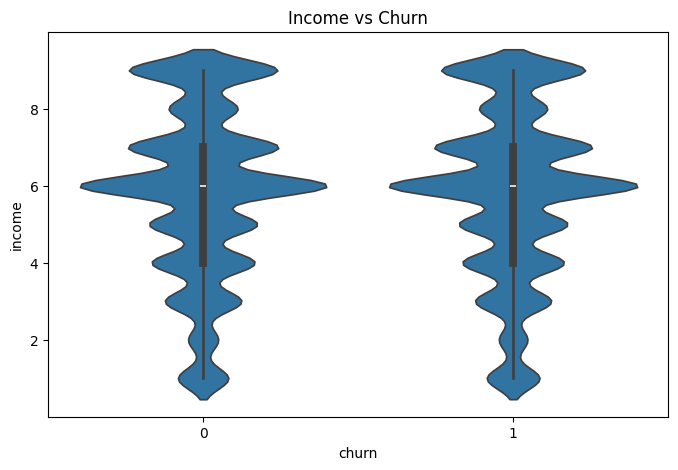

In [ ]:
plt.figure(figsize = (8, 5))
sns.violinplot(x = 'churn', y = 'income', data = df)
plt.title('Income vs Churn')
plt.show()

Decidimos elimianr la columna 'income' principalmente por 3 motivos:
1. Elevada cantidad de registros nulos
2. Es una estimación
3. No vemos correlación con la target

In [ ]:
# eliminamos la columna
df.drop(columns = ['income'], inplace = True)
df_predict.drop(columns = ['income'], inplace = True)


print(f"ELIMIANMOS LA VARIABLE INCOME DEL DATASET.")

ELIMIANMOS LA VARIABLE INCOME DEL DATASET.


In [ ]:
df['adults'].value_counts()

,count
adults,
2.0,21001
1.0,20016
3.0,12429
4.0,8077
5.0,4403
6.0,3958


In [ ]:
corr = df[['churn', 'adults']].corr(numeric_only = True)
corr.style.background_gradient(cmap = 'coolwarm')

,churn,adults
churn,1.000000,-0.010540
adults,-0.010540,1.000000


Decidimos dejar la columna ya que hay un poco mas de correlación

In [ ]:
columnas_numericas = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
columnas_numericas

['rev',
 'mou',
 'totmrc',
 'da',
 'ovrmou',
 'ovrrev',
 'vceovr',
 'datovr',
 'roam',
 'change_mou',
 'change_rev',
 'drop_vce',
 'drop_dat',
 'blck_vce',
 'blck_dat',
 'unan_vce',
 'unan_dat',
 'plcd_vce',
 'plcd_dat',
 'recv_vce',
 'recv_sms',
 'comp_vce',
 'comp_dat',
 'custcare',
 'ccrndmou',
 'cc_mou',
 'inonemin',
 'threeway',
 'mou_cvce',
 'mou_cdat',
 'mou_rvce',
 'owylis_vce',
 'mouowylisv',
 'iwylis_vce',
 'mouiwylisv',
 'peak_vce',
 'peak_dat',
 'mou_peav',
 'mou_pead',
 'opk_vce',
 'opk_dat',
 'mou_opkv',
 'mou_opkd',
 'drop_blk',
 'attempt',
 'complete',
 'callfwdv',
 'callwait',
 'churn',
 'months',
 'uniqsubs',
 'actvsubs',
 'totcalls',
 'totmou',
 'totrev',
 'adjrev',
 'adjmou',
 'adjqty',
 'avgrev',
 'avgmou',
 'avgqty',
 'avg3mou',
 'avg3qty',
 'avg3rev',
 'avg6mou',
 'avg6qty',
 'avg6rev',
 'hnd_price',
 'phones',
 'models',
 'truck',
 'rv',
 'adults',
 'eqpdays',
 'Customer_ID']

In [ ]:
isnull = df.isnull().sum()
isnull[isnull > 0].sort_values(ascending = False)

,0
adults,19981
prizm_social_one,6531
truck,1450
rv,1450
creditcd,1450
avg6mou,1374
avg6qty,1374
avg6rev,1374
hnd_price,703
change_mou,461


In [ ]:
lista_numericas, lista_boolean, lista_categoricas = obtener_lista_variables(df)

In [ ]:
df[lista_numericas].nunique()

,0
rev,35159
mou,9179
totmrc,7676
da,163
ovrmou,2484
ovrrev,11299
vceovr,7143
datovr,689
roam,5047
change_mou,7126


Para tratar los nulos, en las numericas diferenciaremos las que tienen mas de 25 valores unicos y las que menos. Las que tienen menos de 50 valores unicos sueles ser numericas que no tiene sentido aplicar la media, como por ejemplo phones. Los telefonos emitidos pueden ser 5, 6, 10 etc. pero no 6,5.

In [ ]:
# listas para las variables numéricas con más de 50 valores únicos y las que tienen 50 o menos
numericas_mas_25 = []
numericas_menos_25 = []

# iterar sobre las columnas numéricas
for col in df[lista_numericas].columns:
    # contar los valores únicos en la columna
    unique_values = df[col].nunique()

    # separar las columnas según el número de valores únicos
    if unique_values > 25:
        numericas_mas_25.append(col)
    else:
        numericas_menos_25.append(col)

# Mostrar los resultados
print("Numericas con más de 25 valores únicos:", numericas_mas_25)
print("Numericas con 25 o menos valores únicos:", numericas_menos_25)

Numericas con más de 25 valores únicos: ['rev', 'mou', 'totmrc', 'da', 'ovrmou', 'ovrrev', 'vceovr', 'datovr', 'roam', 'change_mou', 'change_rev', 'drop_vce', 'drop_dat', 'blck_vce', 'blck_dat', 'unan_vce', 'unan_dat', 'plcd_vce', 'plcd_dat', 'recv_vce', 'recv_sms', 'comp_vce', 'comp_dat', 'custcare', 'ccrndmou', 'cc_mou', 'inonemin', 'threeway', 'mou_cvce', 'mou_cdat', 'mou_rvce', 'owylis_vce', 'mouowylisv', 'iwylis_vce', 'mouiwylisv', 'peak_vce', 'peak_dat', 'mou_peav', 'mou_pead', 'opk_vce', 'opk_dat', 'mou_opkv', 'mou_opkd', 'drop_blk', 'attempt', 'complete', 'callfwdv', 'callwait', 'months', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'eqpdays', 'Customer_ID']
Numericas con 25 o menos valores únicos: ['uniqsubs', 'actvsubs', 'hnd_price', 'phones', 'models', 'adults']


In [ ]:
for col in numericas_mas_25:
  df[col] = df[col].fillna(df[col].mean())
  df_predict[col] = df_predict[col].fillna(df[col].mean())

In [ ]:
for col in numericas_menos_25:
  df[col] = df[col].fillna(list(df[col].mode())[0])
  df_predict[col] = df_predict[col].fillna(list(df[col].mode())[0])

In [ ]:
for col in lista_categoricas:
  df[col] = df[col].fillna(list(df[col].mode())[0])
  df_predict[col] = df_predict[col].fillna(list(df[col].mode())[0])

In [ ]:
for col in lista_boolean:
  df[col] = df[col].fillna(list(df[col].mode())[0])
  df_predict[col] = df_predict[col].fillna(list(df[col].mode())[0])

In [ ]:
print(df.isnull().sum().sum())
print(df_predict.isnull().sum().sum())

print(f"YA NO TENEMOS NULOS")

0
0
YA NO TENEMOS NULOS


In [ ]:
columnas_bool = df.select_dtypes(include=['bool']).columns.tolist()
columnas_bool

['asl_flag', 'refurb_new', 'infobase', 'creditcd', 'has_kid']

In [ ]:
df[columnas_bool] = df[columnas_bool].astype(int)
df_predict[columnas_bool] = df_predict[columnas_bool].astype(int)

In [ ]:
columnas_objeto = df.select_dtypes(include = ['object']).columns.tolist()
columnas_objeto

['new_cell',
 'crclscod',
 'prizm_social_one',
 'area',
 'dualband',
 'hnd_webcap',
 'marital',
 'ethnic']

# Encoding categóricos

* Si tienen sentido ordinal, es decir, se pueden ordenar, encodear con una escala numerica. Ejemplo: {"Bajo":1, "Medio":2, "Alto":3}.
* Si tienen unicamente 2 clases, indicador booleano
* One Hot Encoding en resto de categoricos

In [ ]:
for col in columnas_objeto:
  print(col)
  print(df[col].unique())
  print(40*'-')

new_cell
['U' 'N' 'Y']
----------------------------------------
crclscod
['A' 'EA' 'OTRO' 'B' 'BA' 'CA' 'AA' 'DA']
----------------------------------------
prizm_social_one
['S' 'U' 'T' 'C' 'R']
----------------------------------------
area
['NORTHWEST/ROCKY MOUNTAIN AREA' 'CHICAGO AREA' 'GREAT LAKES AREA'
 'NEW ENGLAND AREA' 'DALLAS AREA' 'CENTRAL/SOUTH TEXAS AREA' 'OTRA'
 'MIDWEST AREA' 'OHIO AREA' 'SOUTHWEST AREA' 'NEW YORK CITY AREA'
 'ATLANTIC SOUTH AREA' 'CALIFORNIA NORTH AREA' 'DC/MARYLAND/VIRGINIA AREA'
 'NORTH FLORIDA AREA' 'LOS ANGELES AREA']
----------------------------------------
dualband
['Y' 'N' 'OTROS']
----------------------------------------
hnd_webcap
['WCMB' 'WC' 'UNKW']
----------------------------------------
marital
['S' 'M' 'OTROS' 'U']
----------------------------------------
ethnic
['N' 'Z' 'U' 'otro' 'S' 'H' 'G' 'O']
----------------------------------------


No estamos seguros de que las variables categoricas se puedan ordenar, ya que el diccionario no nos indica el significado de cada categoria.

In [ ]:
# hacemos one hot encoding
df_encoded = pd.get_dummies(df, dtype = int)
df_predict_encoded = pd.get_dummies(df, dtype = int)

# Eliminar alta correlación

* Analizar variables (X) altamente correlacionadas
* Eliminar una variable de cada pareja altamente correlacionada (>95% o >99%...) en el dataset (df)

In [ ]:
df_corr = df_encoded.corr(numeric_only = True)

In [ ]:
df_corr.style.background_gradient(cmap='coolwarm')

Nº of days of current equipment es el que tiene mas correlacion con el target y solo tiene un 0,1

In [ ]:
# sacamos los pares de variables muy correlacionadas (positiva o negativamente)

# creamos un dataframe triangulo de las correlaciones para evitar que se repitan los valores
df_triangulo = pd.DataFrame(np.triu(df_corr, k = 1), columns = df_encoded.columns)
df_triangulo.index= df_encoded.columns
df_triangulo

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,change_rev,drop_vce,drop_dat,blck_vce,blck_dat,unan_vce,unan_dat,plcd_vce,plcd_dat,recv_vce,recv_sms,comp_vce,comp_dat,custcare,ccrndmou,cc_mou,inonemin,threeway,mou_cvce,mou_cdat,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,mou_pead,opk_vce,opk_dat,mou_opkv,mou_opkd,drop_blk,attempt,complete,callfwdv,callwait,churn,months,uniqsubs,actvsubs,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,refurb_new,hnd_price,phones,models,truck,rv,adults,infobase,creditcd,eqpdays,Customer_ID,has_kid,new_cell_N,new_cell_U,new_cell_Y,crclscod_A,crclscod_AA,crclscod_B,crclscod_BA,crclscod_CA,crclscod_DA,crclscod_EA,crclscod_OTRO,prizm_social_one_C,prizm_social_one_R,prizm_social_one_S,prizm_social_one_T,prizm_social_one_U,area_ATLANTIC SOUTH AREA,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_OTRA,area_SOUTHWEST AREA,dualband_N,dualband_OTROS,dualband_Y,hnd_webcap_UNKW,hnd_webcap_WC,hnd_webcap_WCMB,marital_M,marital_OTROS,marital_S,marital_U,ethnic_G,ethnic_H,ethnic_N,ethnic_O,ethnic_S,ethnic_U,ethnic_Z,ethnic_otro
rev,0.0,0.715326,0.625768,0.415046,0.798767,0.801377,0.796964,0.149753,0.295897,-0.030483,-0.037365,0.437048,0.056809,0.234670,0.025082,0.452061,0.052143,0.598846,0.115919,0.504015,0.018129,0.610001,0.115394,0.158953,0.245025,0.246898,0.413808,0.206562,0.588358,0.105173,0.602731,0.497159,0.455969,0.371190,0.357741,0.637850,0.103427,0.698494,0.115867,0.469508,0.110096,0.454371,0.085586,0.420856,0.601355,0.612707,0.022643,0.465231,-0.015922,0.005900,-0.013553,-0.038519,0.069772,0.422898,0.501821,0.550628,0.547241,0.501894,0.422985,0.770773,0.594508,0.546165,0.702221,0.637533,0.955729,0.651573,0.595758,0.881270,-0.047596,0.166016,0.244808,0.241038,-0.038589,-0.010454,-0.042862,-0.073421,-0.077308,-0.219359,-0.004168,-0.047380,0.044303,-0.043738,0.012974,-0.057815,-0.091633,0.011731,0.030399,0.046243,0.038742,0.079867,0.049678,0.006478,-0.012885,-0.009452,-0.031932,0.038913,0.009776,0.009429,0.021190,0.001384,0.002783,-0.005318,-0.004594,0.003595,-0.015861,-0.020642,0.018845,-0.016542,-0.010738,-0.019112,0.010137,0.002408,-0.066697,0.034164,0.047984,-0.102095,-0.084950,0.141651,-0.095217,0.019053,0.011082,0.069349,-0.016053,0.036656,-0.016418,-0.037941,-0.004025,-0.009784,0.046784,0.004600
mou,0.0,0.000000,0.579261,0.397424,0.579046,0.542217,0.540946,0.084588,0.115862,-0.040066,-0.038694,0.595583,0.050507,0.323441,0.031737,0.643880,0.053185,0.823024,0.120188,0.699303,0.014554,0.831385,0.120147,0.327715,0.382526,0.370508,0.584339,0.299638,0.861059,0.113241,0.827372,0.697192,0.652776,0.561417,0.553235,0.771423,0.098608,0.813411,0.102844,0.761035,0.122669,0.814282,0.101598,0.574389,0.824356,0.832652,0.021510,0.614539,-0.058390,-0.061679,-0.024036,-0.055852,0.143793,0.558443,0.679995,0.451853,0.447748,0.680315,0.558719,0.661495,0.870095,0.762393,0.984013,0.861602,0.688944,0.941126,0.825300,0.689953,-0.074386,0.224515,0.311119,0.305560,-0.055712,-0.027128,-0.037559,-0.115246,-0.118160,-0.317997,0.088882,-0.056981,0.044419,-0.046823,0.016533,-0.099708,-0.107283,0.002960,0.039237,0.077820,0.063409,0.100334,0.063454,0.020771,-0.032063,-0.016326,-0.049399,0.058803,0.020706,-0.012584,0.039354,0.004937,0.002470,-0.011101,0.002454,-0.000951,-0.025157,-0.034835,0.028424,-0.015853,-0.024001,-0.023412,0.029894,-0.004243,-0.069003,0.051259,0.042584,-0.145340,-0.128113,0.207451,-0.135096,0.006453,0.020655,0.109290,-0.034183,0.060536,-0.042490,-0.002041,-0.021410,-0.009551,0.075764,0.007828
totmrc,0.0,0.000000,0.000000,0.304704,0.200998,0.163846,0.162611,0.032916,0.078143,-0.023928,-0.029705,0.348603,0.035377,0.184186,0.021155,0.3

In [ ]:
# seleccionamos los pares de variables cuya correlación absoluta supere el umbral de 0.9 (dos variables con alta correlación
# significa que me dices practicamente lo mismo, y no es necesario quedarme con ambas)
df_altas_correlaciones = df_triangulo.stack().reset_index()
df_altas_correlaciones.columns = ['variable1', 'variable2', 'correlacion']
df_altas_correlaciones = df_altas_correlaciones[df_altas_correlaciones['correlacion'].abs()>0.9].reset_index()
df_altas_correlaciones

,index,variable1,variable2,correlacion
0,64,rev,avg3rev,0.955729
1,192,mou,avg3mou,0.984013
2,195,mou,avg6mou,0.941126
3,525,ovrmou,ovrrev,0.957400
4,526,ovrmou,vceovr,0.954806
5,656,ovrrev,vceovr,0.994997
6,2231,plcd_vce,comp_vce,0.985669
7,2254,plcd_vce,attempt,0.998549
8,2255,plcd_vce,complete,0.983652
9,2362,plcd_dat,comp_dat,0.990591


In [ ]:
df_corr[abs((df_corr>0.95)) & (df_corr < 1)].stack().reset_index()

,level_0,level_1,0
0,rev,avg3rev,0.955729
1,mou,avg3mou,0.984013
2,ovrmou,ovrrev,0.957400
3,ovrmou,vceovr,0.954806
4,ovrrev,ovrmou,0.957400
5,ovrrev,vceovr,0.994997
6,vceovr,ovrmou,0.954806
7,vceovr,ovrrev,0.994997
8,plcd_vce,comp_vce,0.985669
9,plcd_vce,attempt,0.998549


In [ ]:
df_X = df_encoded.drop("churn", axis=1)
df_X_numeric = df_X.select_dtypes(include=['number'])

In [ ]:
# Mismo analisis, pero desde una funcion que nos facilita la vida
def highly_correlated(X, y, threshold):
    col_corr = list() # Set of all the names of deleted columns
    colnames = list()
    rownames = list()
    corr_matrix = X.corr().abs()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j] >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colnames.append(corr_matrix.columns[i]) # getting the name of column
                rownames.append(corr_matrix.index[j])
                col_corr.append(corr_matrix.iloc[i, j])
    Z = pd.DataFrame({'F1':colnames,
                      'F2':rownames,
                      'corr_F1_F2':col_corr,
                      'corr_F1_target': [np.abs(np.corrcoef(X[i],y)[0,1]) for i in colnames],
                      'corr_F2_target': [np.abs(np.corrcoef(X[i],y)[0,1]) for i in rownames]
                      })
    Z['F_to_delete'] = rownames
    Z['F_to_delete'][Z['corr_F1_target'] < Z['corr_F2_target']] = Z['F1'][Z['corr_F1_target'] < Z['corr_F2_target']]

    return Z

highly_corr = highly_correlated(df_X_numeric,df_encoded['churn'],0.95)
highly_corr

,F1,F2,corr_F1_F2,corr_F1_target,corr_F2_target,F_to_delete
0,ovrrev,ovrmou,0.957400,0.021379,0.016324,ovrmou
1,vceovr,ovrmou,0.954806,0.021583,0.016324,ovrmou
2,vceovr,ovrrev,0.994997,0.021583,0.021379,ovrrev
3,comp_vce,plcd_vce,0.985669,0.049564,0.045934,plcd_vce
4,comp_dat,plcd_dat,0.990591,0.007088,0.007267,comp_dat
5,cc_mou,ccrndmou,0.988748,0.032365,0.033963,cc_mou
6,inonemin,recv_vce,0.965988,0.032599,0.040126,inonemin
7,mou_opkd,mou_cdat,0.960178,0.008144,0.008668,mou_opkd
8,attempt,plcd_vce,0.998549,0.046038,0.045934,plcd_vce
9,attempt,comp_vce,0.984295,0.046038,0.049564,attempt


In [ ]:
to_delete = list(highly_corr["F_to_delete"])
to_delete

['ovrmou',
 'ovrmou',
 'ovrrev',
 'plcd_vce',
 'comp_dat',
 'cc_mou',
 'inonemin',
 'mou_opkd',
 'plcd_vce',
 'attempt',
 'plcd_vce',
 'comp_vce',
 'attempt',
 'totrev',
 'totmou',
 'totcalls',
 'avg3mou',
 'rev',
 'avg6mou',
 'avg6qty']

In [ ]:
# eliminar las columnas altamente correlacionadas en el df de entrenamiento y predicción
df_encoded.drop(columns = to_delete, inplace = True)
df_predict_encoded.drop(columns = to_delete, inplace = True)

# Eliminar baja varianza

* Eliminar variables (X) practicamente constantes con un threshold minimo (1% o menos)

In [ ]:
var_poca_varianza = []

for col in df_encoded.select_dtypes(include = "number").columns:
  if df_encoded[col].var() < 0.01:
    var_poca_varianza.append(col)
print('Eliminar: ', var_poca_varianza)

Eliminar:  []


In [ ]:
df_encoded.drop(columns = var_poca_varianza, inplace=True)
df_predict_encoded.drop(columns = var_poca_varianza, inplace=True)

In [ ]:
df_corr = df_encoded.corr(numeric_only = True)

In [ ]:
df_corr.style.background_gradient(cmap='coolwarm')

# Guardar clean data

* Guardar en data path y mostrar el resultado en un head()

In [ ]:
for i in df_encoded.columns:
    df_encoded[i] = pd.to_numeric(df_encoded[i], downcast = "float")
    df_predict_encoded[i] = pd.to_numeric(df_predict_encoded[i], downcast = "float")

In [ ]:
df_encoded.drop('Customer_ID', axis = 1, inplace = True)

In [ ]:
df_predict_encoded.drop('churn', axis = 1, inplace = True)

In [ ]:
df_encoded.to_pickle('/content/drive/MyDrive/Master_Data_Science/Aprendizaje supervisado/DSC-0924-Entregable 2-Buixeda_Urbina_Longobardi_Farres/df_encoded.pkl')
df_predict_encoded.to_pickle('/content/drive/MyDrive/Master_Data_Science/Aprendizaje supervisado/DSC-0924-Entregable 2-Buixeda_Urbina_Longobardi_Farres/df_predict_encoded.pkl')


In [ ]:
data = pd.read_pickle('/content/drive/MyDrive/Master_Data_Science/Aprendizaje supervisado/DSC-0924-Entregable 2-Buixeda_Urbina_Longobardi_Farres/df_encoded.pkl')
data.head(10)

,mou,totmrc,da,vceovr,datovr,roam,change_mou,change_rev,drop_vce,drop_dat,blck_vce,blck_dat,unan_vce,unan_dat,plcd_dat,recv_vce,recv_sms,custcare,ccrndmou,threeway,mou_cvce,mou_cdat,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,mou_pead,opk_vce,opk_dat,mou_opkv,drop_blk,complete,callfwdv,callwait,churn,months,uniqsubs,actvsubs,asl_flag,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3qty,avg3rev,avg6rev,refurb_new,hnd_price,phones,models,truck,rv,adults,infobase,creditcd,eqpdays,has_kid,new_cell_N,new_cell_U,new_cell_Y,crclscod_A,crclscod_AA,crclscod_B,crclscod_BA,crclscod_CA,crclscod_DA,crclscod_EA,crclscod_OTRO,prizm_social_one_C,prizm_social_one_R,prizm_social_one_S,prizm_social_one_T,prizm_social_one_U,area_ATLANTIC SOUTH AREA,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_OTRA,area_SOUTHWEST AREA,dualband_N,dualband_OTROS,dualband_Y,hnd_webcap_UNKW,hnd_webcap_WC,hnd_webcap_WCMB,marital_M,marital_OTROS,marital_S,marital_U,ethnic_G,ethnic_H,ethnic_N,ethnic_O,ethnic_S,ethnic_U,ethnic_Z,ethnic_otro
0,219.25,22.500000,0.2475,0.000000,0.0,0.0,-157.25,-18.997499,0.666667,0.0,0.666667,0.0,6.333333,0.0,0.0,42.333332,0.0,0.000000,0.000000,0.000000,90.643333,0.0,97.176666,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600006,0.0,24.000000,0.0,55.220001,1.333333,45.000000,0.0,0.333333,1.0,61.0,2.0,1.0,0.0,1453.44,4085.00,1602.0,29.660000,83.370003,32.689999,116.0,30.0,38.0,1.0,149.98999,2.0,2.0,0.0,0.0,1.0,1.0,1.0,361.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,482.75,37.424999,0.2475,9.100000,0.0,0.0,532.25,50.987499,8.333333,0.0,1.000000,0.0,61.333332,0.0,0.0,69.000000,0.0,1.666667,6.333333,0.333333,189.396667,0.0,55.279999,46.333332,24.216667,6.333333,3.696667,83.666664,0.0,75.333336,0.0,157.000000,0.0,169.343338,9.333333,193.333328,0.0,5.666667,0.0,56.0,1.0,1.0,0.0,2833.88,26367.00,14624.0,51.529999,479.399994,265.890015,158.0,40.0,48.0,1.0,29.98999,7.0,6.0,1.0,1.0,1.0,1.0,1.0,240.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,10.25,16.990000,0.0000,0.000000,0.0,0.0,-4.25,0.000000,0.333333,0.0,0.000000,0.0,2.666667,0.0,0.0,0.333333,0.0,0.000000,0.000000,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.333333,6.000000,0.0,0.000000,1.0,58.0,1.0,1.0,0.0,1934.47,24303.05,7888.0,34.540001,433.980011,140.860001,7.0,17.0,17.0,1.0,29.98999,2.0,1.0,0.0,0.0,2.0,1.0,1.0,1504.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,7.50,38.000000,0.0000,0.000000,0.0,0.0,-1.50,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,1.333333,0.0,0.000000,0.000000,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.000000,3.666667,0.0,0.000000,0.0,60.0,1.0,1.0,0.0,1941.81,3035.00,1479.0,40.450001,63.230000,30.809999,3.0,38.0,40.0,1.0,29.98999,1.0,1.0,0.0,0.0,4.0,1.0,1.0,1812.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,570.50,71.980003,0.0000,0.000000,0.0,0.0,38.50,0.000000,9.666667,0.0,0.666667,0.0,77.000000,0.0,0.0,94.666664,0.0,8.666667,15.000000,0.000000,285.233337,0.0,106.330002,14.666667,10